**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 3b: Discrete Markov Chains & Detailed Balance](03b_markov_chains_and_detailed_balance.ipynb) | ⏭️ Next: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb)**

---

# Sheet 4: First Principles — Metropolis-Hastings MCMC Mechanics from Scratch
### *Sampling Complex Posteriors When Quadratic Approximations Fail*

In **Sheet 2**, we saw that Grid Approximation cannot scale past 3 parameters. In **Sheet 3**, we saw that Quadratic (Laplace) Approximation scales to dozens of parameters but assumes a symmetric Gaussian bell curve, failing on skewed, bounded, or multimodal distributions.

In this sheet, we build the ultimate engine of modern Bayesian computation: **Markov Chain Monte Carlo (MCMC)**. We implement the **Metropolis-Hastings algorithm from scratch** with zero external libraries, understand the ergodic physics of random walkers, prove why the intractable denominator cancels, and discover the step-size Goldilocks zone.

> [!NOTE]
> ### 🗺️ The Big Picture: Where We Are on the Mountain
> * **The Boss Battle**: The intractable evidence integral $P(y) = \int \mathcal{L}(y \mid \theta) P(\theta) \, d\theta$ prevents us from calculating continuous Bayesian posteriors analytically.
> * **How We Got Here**:
>   1. In **Sheet 3**, Laplace Approximation gave us a quick parabolic estimate near the peak, but failed on bounded, heavy-tailed, or irregular parameter geometries.
>   2. In **Sheet 3b**, we proved mathematically that any Markov chain satisfying **Detailed Balance** ($\pi(A) T(A \to B) = \pi(B) T(B \to A)$) cancels out the denominator $P(y)$ in the acceptance ratio $\alpha = \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$.
> * **The Mission of Sheet 4**: To translate that mathematical proof into executable code—building a continuous **Metropolis-Hastings MCMC sampler from scratch**, mastering proposal step-size tuning ($\tau$), diagnosing autocorrelation, and computing Effective Sample Size ($ESS$).
> * **Where This Leads**: In **Sheet 5**, we scale to multi-chain convergence diagnostics ($\hat{R}$), trace rank plots, WAIC/LOO model comparison, and Stan's gradient-powered Hamiltonian Monte Carlo (HMC).

---


## Table of Contents
1. **Part 1: The Intuition — King Markov and the Island Kingdom**
   - 1.0 The Motivation: Escaping the Traps of Grid & Laplace
   - 1.1 The Island Kingdom Metaphor & Daily Protocol
2. **Part 2: 1D Metropolis from Scratch — Interleaved Deep Dives & Code**
   - Step 1: Recreating the Calibration Dataset ($n = 50$)
   - **Step 2 & Deep Dive 1**: The Target Log-Posterior & Denominator Cancellation
   - **Step 3 & Deep Dives 2 & 3**: Detailed Balance Equilibrium & The 3-Step Metropolis Kernel
   - Step 4: Executing the Full Markov Chain Walker (`run_1d_mcmc`)
   - Step 5: Visualizing Traceplot Stationarity & Posterior Recovery
3. **Part 3: Step-Size ($\tau$) Tuning & The Acceptance Goldilocks Zone**
   - Step 6: Simulating the Three Tuning Regimes (Too Small, Too Large, Optimal)
   - Step 7: Diagnosing Sluggish Brownian Diffusion vs. Frozen Flatlines ($23.4\% \text{--} 44\%$)
4. **Part 4: Autocorrelation, Memory Decay & Effective Sample Size ($ESS$)**
   - **Deep Dive 4**: What is Autocorrelation in Markov Chains?
   - Step 8: Computing Lag Autocorrelation & The Memory Decay Profile
   - Step 9: Computing Effective Sample Size ($ESS$) & The Truth About Thinning
5. **Part 5: Multi-Parameter Joint Metropolis: Estimating Mean ($\mu$) and Spread ($\sigma$)**
   - Step 10: Formulating the 2D Joint Log-Posterior Target
   - Step 11: Running the 2D Correlated Walker & Validating against Sheet 2 & Sheet 3
6. **Part 6: The Curse of Volume & The Leap to Hamiltonian Monte Carlo (HMC)**
   - Understanding the Curse of Volume (Why Random Walks Scale as $\mathcal{O}(D^2)$ Diffusion)
   - Looking Forward to Sheet 5 (Multi-Chain Diagnostics & Stan HMC)
7. **Part 7: Check Your Understanding (3-Tier Scaffolding Exercises)**

## Part 1: The Intuition — King Markov and the Island Kingdom

### 1.0 The Motivation: Escaping the Traps of Grid & Laplace
Before meeting King Markov, consider why computational statistics needed to invent **Markov Chain Monte Carlo (MCMC)**:
1. **The Grid Dies in High Dimensions**: In **Sheet 2**, our 2D grid of $300 \times 300 = 90,000$ points ran in ~0.2 seconds. But as we proved in **Sheet 3**, adding parameters causes an exponential explosion ($\mathcal{O}(G^k)$). A 10-parameter regression model takes $300^{10} \approx 10^{24}$ evaluations—requiring **187 billion years** of computation!
2. **Laplace is Blind to Non-Gaussian Geometry**: In **Sheet 3**, Laplace (QUAP) solved the speed problem by sprinting to the peak via gradients in milliseconds. But Laplace forces a rigid, symmetric Multivariate Normal ellipse over the peak. If the posterior has **two competing peaks** (multimodality), **curved banana-shaped funnels** (hierarchical variance shrinkage), or **heavy tails**, Laplace fails catastrophically.

**The MCMC Breakthrough**:
MCMC is the universal general-purpose workhorse of modern Bayesian inference. It never evaluates an empty grid, nor does it force an artificial Gaussian bell curve. Instead, it deploys an intelligent stochastic walker that spends its time wandering through parameter space in **exact proportion to the posterior probability density**.

---

### 1.1 The Island Kingdom Metaphor
Imagine a benevolent monarch—**King Markov**—ruling an archipelago of islands arranged in a circle. Each island has a different population:
- Island 1 has 1,000 citizens.
- Island 2 has 2,000 citizens.
- Island 7 has 7,000 citizens.

The King wants to spend his time visiting each island in **exact proportion to its population** (spending 7 times as much time on Island 7 as on Island 1). However, the King is blindfolded, has no map of the kingdom, and does not know the total population of all islands combined.

### The King's Daily Protocol:
Every day, King Markov uses a simple rule:
1. **Flip a coin** to choose a neighboring island to visit (left or right).
2. **Send a royal scout** to measure the population of the candidate island ($P_{\text{prop}}$) and compare it to current island ($P_{\text{curr}}$).
3. **The Decision Rule**:
   - If the candidate island has **more people** ($P_{\text{prop}} > P_{\text{curr}}$), the King **always moves** there!
   - If the candidate island has **fewer people**, he moves with probability $\alpha = \frac{P_{\text{prop}}}{P_{\text{curr}}}$. He spins a wheel of fortune: with probability $\alpha$ he moves; otherwise, he stays put and drinks tea for another day on his current island.

> **The Miracle**: Over a year of recording his daily location, the King's visit history will match the island populations **with 100% mathematical precision**—without ever knowing the total population of the kingdom!


## Part 2: 1D Metropolis Implementation from Scratch — Interleaved Deep Dives & Code
### *Translating Theory into Executable Algorithms*

Let us test our first-principles walker on estimating population mean height $\mu$, assuming known $\sigma = 8.0$ for clear 1D visualization.

### Why Are We Covering These Deep Dives? (The Practitioner's Compass)
Before writing the MCMC walker from scratch, consider why these mathematical deep dives are essential for every applied practitioner:
1. **Why Denominator Cancellation Matters (Deep Dive 1)**: Proves why MCMC completely sidesteps the intractable evidence integral $P(y) = \int \mathcal{L} P \, d\theta$, explaining why a simple ratio of unnormalized densities is all that is needed to sample from the exact posterior.
2. **Why Detailed Balance Guarantees Correctness (Deep Dive 2)**: Proves that probability flows into every state exactly equal probability flows out, guaranteeing that the chain's long-run histogram converges to the true Bayesian posterior.
3. **Why the 3-Step Decision Kernel Works (Deep Dive 3)**: Translates the abstract equilibrium equations into three executable lines of code: Propose a candidate, compute the acceptance probability $\alpha$ in log-space, and flip a uniform coin.

---

### Step 1: Recreating the Calibration Dataset ($n = 50$)
We recreate the exact adult height dataset used in **Sheet 2** (Grid) and **Sheet 3** (Laplace) to verify that MCMC recovers the identical posterior.

In [1]:

# --- Step 1: Recreate the identical dataset from Sheet 2 & 3 ---
set.seed(42)
n <- 50
heights <- rnorm(n, mean = 172.5, sd = 8.0)

cat(sprintf("Recreated dataset: %d observations | Mean: %.2f cm | SD: %.2f cm\n", n, mean(heights), sd(heights)))


Recreated dataset: 50 observations | Mean: 172.21 cm | SD: 9.21 cm


---

### Step 2 & Deep Dive 1: Defining the Target Log-Posterior Function & Denominator Cancellation

Recall Bayes' Theorem:
$$P(\mu \mid y) = \frac{\mathcal{L}(y \mid \mu) P(\mu)}{P(y)} = \frac{\mathcal{L}(y \mid \mu) P(\mu)}{\int \mathcal{L}(y \mid \mu) P(\mu) \, d\mu}$$

In higher dimensions, calculating the evidence integral $P(y) = \int \mathcal{L} \cdot P \, d\theta$ is practically impossible. But in the Metropolis algorithm, we only evaluate the **ratio** of posterior probabilities between proposed $\mu^*$ and current $\mu^{(t)}$:

$$\frac{P(\mu^* \mid y)}{P(\mu^{(t)} \mid y)} = \frac{\frac{\mathcal{L}(y \mid \mu^*) P(\mu^*)}{P(y)}}{\frac{\mathcal{L}(y \mid \mu^{(t)}) P(\mu^{(t)})}{P(y)}} = \frac{\mathcal{L}(y \mid \mu^*) P(\mu^*)}{\mathcal{L}(y \mid \mu^{(t)}) P(\mu^{(t)})}$$

> **The Normalizing Constant $P(y)$ Cancels Completely!**  
> We only ever need to evaluate the unnormalized posterior: Likelihood $\times$ Prior.  
> In log-space, this becomes a simple sum:
> $$\log P(\mu \mid y) = \sum_{i=1}^n \log \mathcal{N}(y_i \mid \mu, 8.0) + \log \mathcal{N}(\mu \mid 170, 15)$$

Working in log-space prevents numerical underflow (multiplying 50 tiny probabilities yields numbers like $10^{-75}$, which crash to 0.0 in standard floating point arithmetic).

> [!WARNING]
> ### ⚠️ The Double-Edged Sword of Denominator Cancellation (The Positive Recurrence Blind Spot)
> Skipping the evidence integral $Z = P(y) = \int \mathcal{L} \cdot P \, d\theta$ is what makes MCMC computationally feasible for complex Bayesian models.
> 
> **However, this denominator cancellation creates a critical blind spot**:
> The Metropolis algorithm only ever sees the **relative ratio** $\frac{q(\mu^*)}{q(\mu^{(t)})}$. The algorithm has **no idea** whether the normalizing integral $Z = \int q(\mu) \, d\mu$ is finite ($Z < \infty$) or infinite ($Z = \infty$)!
> 
> * If a practitioner accidentally uses a pathological flat prior or an under-identified model where $Z = \infty$ (an **improper posterior**, as introduced in **Sheet 3b: Condition C**), the software will not throw an error.
> * Instead, the Markov chain violates **Positive Recurrence**: the target is not a legitimate PDF, the expected return time $\mathbb{E}[T] = \infty$, and the walker will silently drift into the unbounded tails without ever converging to a stationary distribution.
> * *Always ensure your posterior is mathematically proper (has finite total mass) before trusting MCMC samples!*

In the code cell below, notice that our target function simply sums the log-likelihood and log-prior:

In [2]:

# --- Step 2: Define the unnormalized target log-posterior for mu ---
target_log_posterior_mu <- function(mu) {
  # Likelihood: sum of log dnorm
  log_lik <- sum(dnorm(heights, mean = mu, sd = 8.0, log = TRUE))
  # Prior: mu ~ Normal(170, 15)
  log_prior <- dnorm(mu, mean = 170, sd = 15, log = TRUE)
  return(log_lik + log_prior)
}


---

### Step 3 & Deep Dives 2 & 3: Detailed Balance & The 3-Step Metropolis Kernel

#### Deep Dive 2: Detailed Balance & The Stationary Distribution
Why is the posterior distribution guaranteed to be the stationary equilibrium of this random walk?

A Markov chain reaches a stationary distribution $\pi(\theta)$ if the probability flow between every pair of states $A$ and $B$ is in exact equilibrium (**Detailed Balance**):
$$\pi(A) \cdot T(A \to B) = \pi(B) \cdot T(B \to A)$$
where $T(A \to B)$ is the transition probability from state $A$ to state $B$.

> [!TIP]
> **Need an Intuitive Primer on Markov Chains & Detailed Balance?**  
> If probability flows and transition matrices feel abstract, explore **[Sheet 3b: Discrete Markov Chains, Stationary Equilibrium & Detailed Balance](03b_markov_chains_and_detailed_balance.ipynb)** for a visual, first-principles guide using 3-island random walks, transition matrices, and an interactive detailed-balance flux auditor.

With a symmetric proposal distribution $q(A \to B) = q(B \to A)$ (e.g. Gaussian centered at current position $\mathcal{N}(\theta^{(t)}, \tau^2)$):
$$T(A \to B) = q(A \to B) \cdot \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$$

Multiplying by $\pi(A)$:
$$\pi(A) T(A \to B) = q(A \to B) \cdot \min(\pi(A), \pi(B)) = q(B \to A) \cdot \min(\pi(B), \pi(A)) = \pi(B) T(B \to A)$$

Because detailed balance holds identically for all states, the posterior distribution $P(\theta \mid y)$ is the **unique, invariant stationary distribution** of the Markov chain.

---

#### Deep Dive 3: The 3-Step Probabilistic Decision Kernel (`metropolis_step`)

To implement this transition probability $T(\theta \to \theta^*)$ in code, each iteration executes three exact steps:

```text
 ┌────────────────────────────────────────────────────────────────────────┐
 │                   THE METROPOLIS ITERATION LOOP                        │
 └────────────────────────────────────────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ STEP 1: PROPOSE A CANDIDATE MOVE                                       │
 │   Perturb current position θ_t with Gaussian proposal noise:           │
 │   θ* = θ_t + Normal(0, τ²)                                             │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ STEP 2: EVALUATE THE ACCEPTANCE RATIO IN LOG-SPACE                     │
 │   Compute relative posterior probability in log-space:                 │
 │   log α = min(0, log P(θ*|y) - log P(θ_t|y))                           │
 │   ► If proposed state is uphill (log P* > log P_t): log α = 0 (α = 1)   │
 │   ► If proposed state is downhill: log α < 0 (α ∈ (0, 1))              │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ STEP 3: STOCHASTIC DECISION RULE (COIN FLIP)                           │
 │   Draw random uniform coin flip: u ~ Uniform(0, 1)                     │
 │   ► If log(u) < log α: ACCEPT proposal! θ_{t+1} = θ*                   │
 │   ► If log(u) ≥ log α: REJECT proposal! θ_{t+1} = θ_t (Stay in place!) │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ STEP 4: RECORD & ADVANCE                                               │
 │   Append θ_{t+1} to trace array, advance t ◄─ t + 1, repeat N times.   │
 └────────────────────────────────────────────────────────────────────────┘
```

> **Crucial Rule**: When a proposal is rejected, you **must re-record the current position** in your chain. Rejections are not discarded; they represent regions of low probability that the chain must not enter, ensuring the correct density weighting!

In the code cell below, we implement `metropolis_step` directly from these 3 steps:

In [3]:

# --- Step 3: Implement the 3-step Metropolis transition kernel ---
metropolis_step <- function(current_mu, step_size = 2.0) {
  # 1. Propose candidate
  proposed_mu <- current_mu + rnorm(1, mean = 0, sd = step_size)
  
  # 2. Ratio in log-space
  log_alpha <- target_log_posterior_mu(proposed_mu) - target_log_posterior_mu(current_mu)
  
  # 3. Stochastic coin flip
  if (log(runif(1)) < log_alpha) {
    return(list(mu = proposed_mu, accepted = TRUE))
  } else {
    return(list(mu = current_mu, accepted = FALSE))
  }
}


---

### Step 4: Executing the Markov Chain Walker (`run_1d_mcmc`)
We initialize the walker far from the peak at $\mu_0 = 145\text{ cm}$ to observe its uphill trek into the high-probability region. We run $4{,}000$ iterations and discard the first $500$ warmup draws.


In [4]:

# --- Step 4: Execute the full Markov chain walker ---
run_1d_mcmc <- function(n_steps = 4000, start_mu = 145, step_size = 2.0) {
  samples  <- numeric(n_steps)
  accepted <- 0
  curr     <- start_mu
  
  for (t in 1:n_steps) {
    res <- metropolis_step(curr, step_size = step_size)
    if (res$accepted) accepted <- accepted + 1
    curr       <- res$mu
    samples[t] <- curr
  }
  
  return(list(samples = samples, accept_rate = accepted / n_steps))
}

# Execute walker starting far away at mu = 145 cm
fit <- run_1d_mcmc(n_steps = 4000, start_mu = 145, step_size = 2.0)
fit_samples <- fit$samples
accept_rate <- fit$accept_rate

cat("=== 1D MCMC Run Results (Pure Base R) ===\n")
cat(sprintf("Total Steps:     %d\n", length(fit_samples)))
cat(sprintf("Acceptance Rate: %.1f%%\n", accept_rate * 100))
post_warmup <- fit_samples[501:length(fit_samples)]
cat(sprintf("Posterior Mean:  %.2f cm (Discarding first 500 warmup steps)\n", mean(post_warmup)))
cat(sprintf("Posterior SD:    %.3f cm\n", sd(post_warmup)))


=== 1D MCMC Run Results (Pure Base R) ===


Total Steps:     4000


Acceptance Rate: 52.2%


Posterior Mean:  172.24 cm (Discarding first 500 warmup steps)


Posterior SD:    1.123 cm


### Step 5: Visualizing Traceplot Stationarity & Posterior Recovery
We plot the traceplot (verifying burn-in / warmup convergence from $145\text{ cm}$) and overlay the recovered posterior density against the frequentist sample mean.


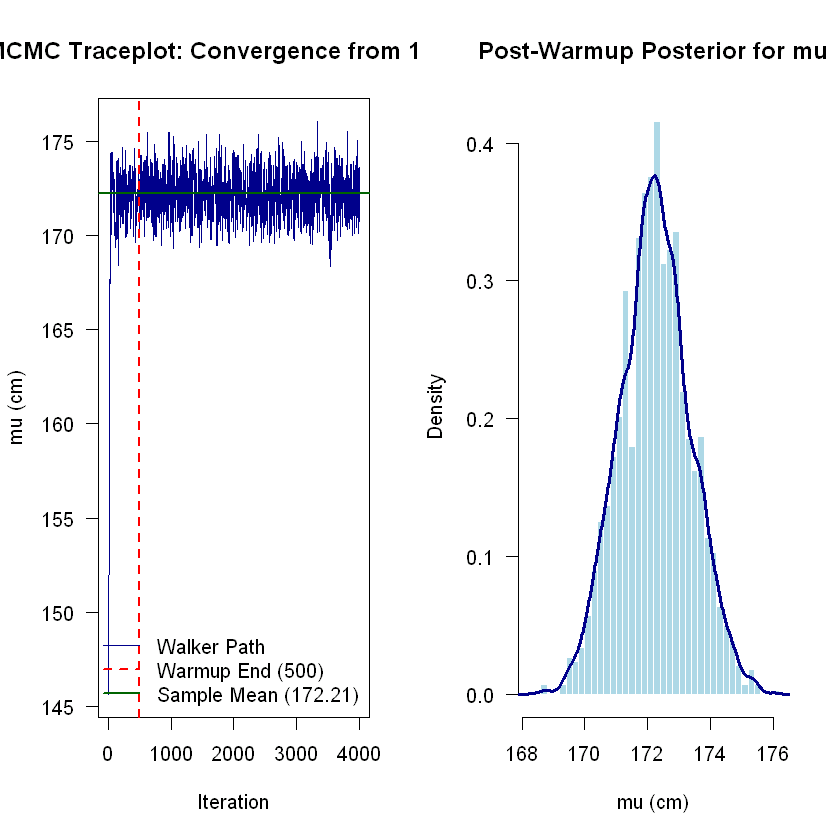

In [5]:

# --- Step 5: Visual inspection - Traceplot & Posterior Distribution ---
par(mfrow = c(1, 2))

plot(fit_samples, type = "l", col = "darkblue", las = 1,
     main = "MCMC Traceplot: Convergence from 145cm",
     xlab = "Iteration", ylab = "mu (cm)")
abline(v = 500, col = "red", lty = 2, lwd = 2)
abline(h = mean(heights), col = "darkgreen", lwd = 2)
legend("bottomright", legend = c("Walker Path", "Warmup End (500)", sprintf("Sample Mean (%.2f)", mean(heights))),
       col = c("darkblue", "red", "darkgreen"), lty = c(1, 2, 1), lwd = c(1, 2, 2), bty = "n")

hist(post_warmup, breaks = 30, col = "lightblue", border = "white", freq = FALSE, las = 1,
     main = "Post-Warmup Posterior for mu", xlab = "mu (cm)")
lines(density(post_warmup), col = "darkblue", lwd = 2.5)

par(mfrow = c(1, 1))


> [!TIP]
> ### 💡 The Acceptance Rate "Goldilocks Zone" (Optimal Scaling Theory)
>
> What acceptance rate should you target when tuning proposal step size $\tau$?
> - **1D Models**: Optimal acceptance rate is **$\approx 44\%$** (Gelman, Roberts, & Gilks, 1996).
> - **High-Dimensional Models ($D \to \infty$)**: The theoretical optimal acceptance rate is **$23.4\%$** (Roberts & Rosenthal, 2001).
> - **The Production Trade-off**:
>   - **Rate $> 60\%$** (Step size too small): Walker accepts nearly every proposal, but moves via slow Brownian diffusion (wasting millions of iterations to explore the posterior).
>   - **Rate $< 10\%$** (Step size too large): Walker proposes points outside the typical set, gets repeatedly rejected, and stays frozen for hundreds of iterations at a time.
>   - Modern samplers like HMC / NUTS automate this completely by adaptively tuning step sizes during warmup to hit exactly $80\%$ target acceptance!

---

## Part 3: Phase IV — Step-Size ($\tau$) Tuning & The Acceptance Goldilocks Zone
### *Diagnosing Sluggish Diffusion vs. Frozen Flatlines*

The performance of a Metropolis sampler depends entirely on the proposal step size $\tau$:

1. **Step Size Too Small ($\tau = 0.1$)**: The proposal $\theta^*$ is so close to $\theta^{(t)}$ that $P(\theta^*) \approx P(\theta^{(t)})$, yielding an acceptance rate $> 95\%$. But the walker moves via sluggish Brownian diffusion.
2. **Step Size Too Large ($\tau = 35.0$)**: The candidate $\theta^*$ lands far out in the low-probability tails. Almost every proposal is rejected ($< 2\%$ acceptance rate), freezing the walker for hundreds of steps.
3. **Optimal Step Size ($\tau = 2.5$)**: Balances exploration and acceptance, producing Gelman's optimal acceptance rate ($\sim 23.4\% - 44\%$).

---

### Step 6: Simulating the Three Tuning Regimes
We simulate 3,000 steps with $\tau = 0.1$ (too small), $\tau = 35.0$ (too large), and $\tau = 2.5$ (optimal).


In [6]:

# --- Step 6: Simulate the three tuning regimes ---
set.seed(42)
chain_tiny  <- run_1d_mcmc(3000, start_mu = 172, step_size = 0.1)
chain_huge  <- run_1d_mcmc(3000, start_mu = 172, step_size = 35.0)
chain_ideal <- run_1d_mcmc(3000, start_mu = 172, step_size = 2.5)


### Step 7: Diagnosing Visual Signatures of Mixing
Notice the stark visual contrast across the three regimes: sluggish brownian drift vs. frozen blocky plateaus vs. the ideal "fuzzy caterpillar" that rapidly explores the target.


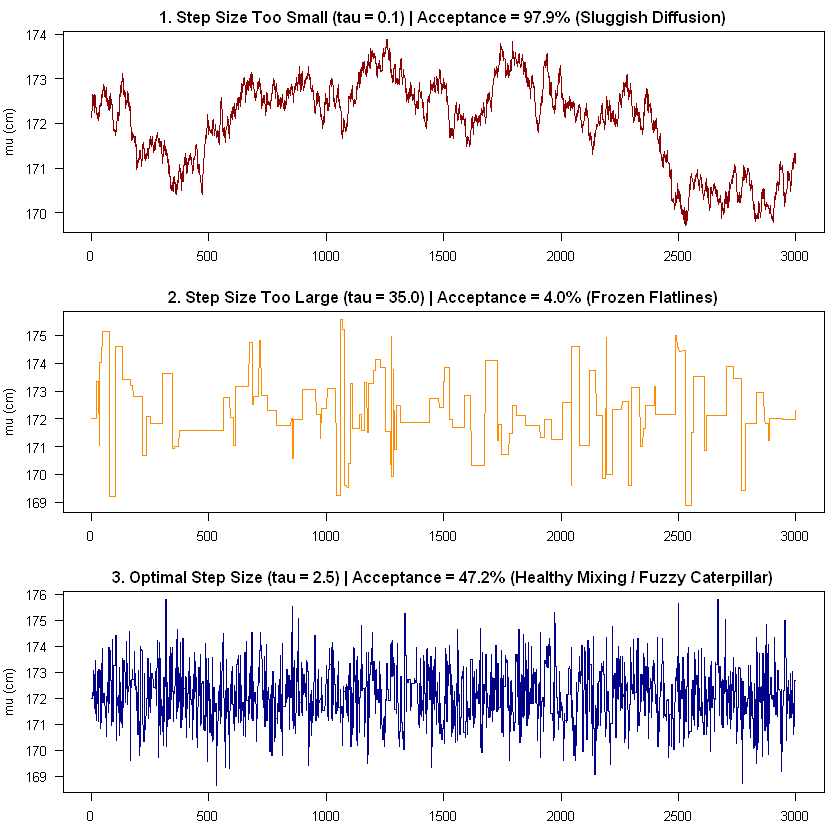

In [7]:

# --- Step 7: Visualize mixing signatures across the 3 regimes ---
par(mfrow = c(3, 1), mar = c(3, 4, 2, 1))
plot(chain_tiny$samples, type = "l", col = "darkred", las = 1,
     main = sprintf("1. Step Size Too Small (tau = 0.1) | Acceptance = %.1f%% (Sluggish Diffusion)", 
                    chain_tiny$accept_rate * 100), ylab = "mu (cm)")
plot(chain_huge$samples, type = "l", col = "darkorange", las = 1,
     main = sprintf("2. Step Size Too Large (tau = 35.0) | Acceptance = %.1f%% (Frozen Flatlines)", 
                    chain_huge$accept_rate * 100), ylab = "mu (cm)")
plot(chain_ideal$samples, type = "l", col = "darkblue", las = 1,
     main = sprintf("3. Optimal Step Size (tau = 2.5) | Acceptance = %.1f%% (Healthy Mixing / Fuzzy Caterpillar)", 
                    chain_ideal$accept_rate * 100), ylab = "mu (cm)", xlab = "Iteration")
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1)


## Part 4: Phase V — Markov Chain Memory Decay & Effective Sample Size ($ESS$)
### *Quantifying the Cost of Autocorrelation*

### Deep Dive 4: What is Autocorrelation in Markov Chains?

In Grid approximation (**Sheet 2**) or Laplace approximation (**Sheet 3**), every sample drawn is **statistically independent (i.i.d.)**. If you draw 10,000 samples, you have 10,000 completely independent pieces of information.

In MCMC, consecutive samples are **dependent** because $\theta^{(t+1)}$ starts where $\theta^{(t)}$ was. The **Autocorrelation at lag $k$** measures this memory:
$$\rho_k = \text{Cor}\left(\theta^{(t)}, \theta^{(t+k)}\right)$$

- In a healthy chain, $\rho_k$ decays exponentially to 0 as lag $k$ increases.
- In a sluggish chain (small step size), $\rho_k$ remains high even at lag 30!

---

### Step 8: Computing Lag Autocorrelation & The Memory Decay Profile
We compute the autocorrelation function (ACF) across lags $k = 0, \dots, 40$ to visualize how fast the walker forgets its past states.


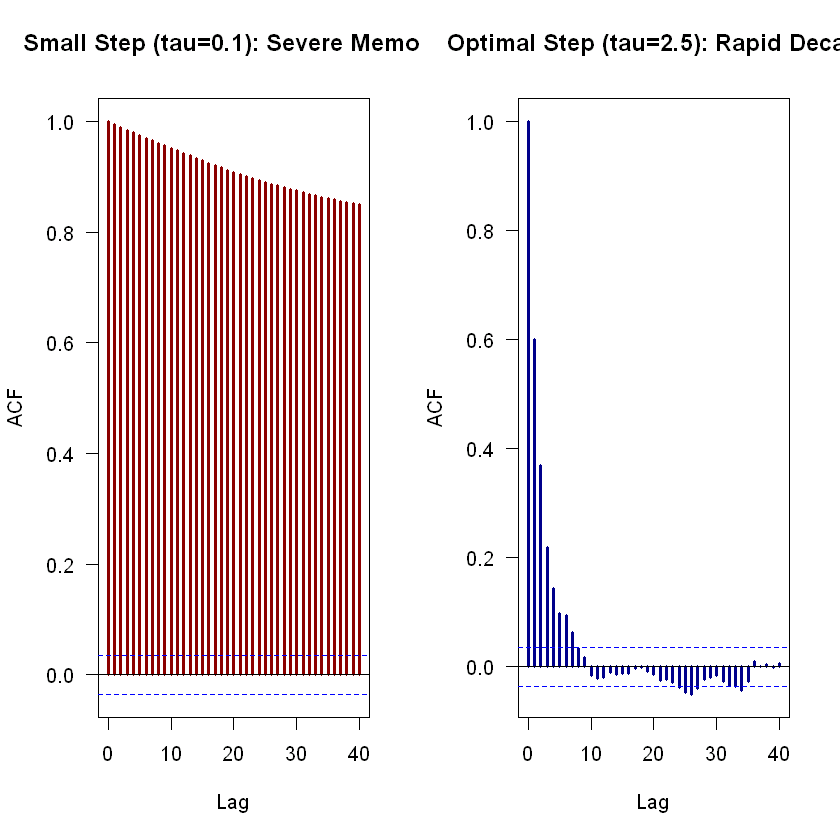

In [8]:

# --- Step 8: Compute lag autocorrelation profiles ---
par(mfrow = c(1, 2))
acf(chain_tiny$samples, lag.max = 40, col = "darkred", lwd = 2.5, las = 1,
    main = "Small Step (tau=0.1): Severe Memory")
acf(chain_ideal$samples, lag.max = 40, col = "darkblue", lwd = 2.5, las = 1,
    main = "Optimal Step (tau=2.5): Rapid Decay")
par(mfrow = c(1, 1))


### Step 9: Effective Sample Size ($ESS$) & The Truth About Thinning
Due to autocorrelation, $N = 3000$ MCMC iterations does **not** equal 3000 independent samples. The **Effective Sample Size ($ESS$)** tells you how many independent samples your chain is worth:
$$ESS = \frac{N}{1 + 2 \sum_{k=1}^\infty \rho_k} \approx N \frac{1 - \rho_1}{1 + \rho_1}$$

> [!NOTE]
> **The Truth About Thinning**: In older literature, researchers "thinned" chains (e.g. keeping only every 10th draw) to remove autocorrelation. Today, thinning is largely recognized as wasteful—discarding draws throws away real information about the posterior! Thinning is only justified when saving disk storage or RAM for massive models.


In [9]:

# --- Step 9: Estimate Effective Sample Size (ESS) ---
rho1_tiny  <- acf(chain_tiny$samples, plot = FALSE)$acf[2]
rho1_ideal <- acf(chain_ideal$samples, plot = FALSE)$acf[2]

ess_tiny  <- length(chain_tiny$samples) * (1 - rho1_tiny) / (1 + rho1_tiny)
ess_ideal <- length(chain_ideal$samples) * (1 - rho1_ideal) / (1 + rho1_ideal)

cat("=== Effective Sample Size (ESS) Comparison (N = 3000 total iterations) ===\n")
cat(sprintf("Small Step (tau = 0.1):   Lag-1 Cor = %.3f | Approx ESS = %d (Massive information loss!)\n", 
            rho1_tiny, round(ess_tiny)))
cat(sprintf("Optimal Step (tau = 2.5): Lag-1 Cor = %.3f | Approx ESS = %d (High information efficiency!)\n", 
            rho1_ideal, round(ess_ideal)))


=== Effective Sample Size (ESS) Comparison (N = 3000 total iterations) ===


Small Step (tau = 0.1):   Lag-1 Cor = 0.995 | Approx ESS = 8 (Massive information loss!)


Optimal Step (tau = 2.5): Lag-1 Cor = 0.600 | Approx ESS = 751 (High information efficiency!)


## Part 5: Phase VI — Multi-Parameter Joint Metropolis from Scratch
### *Exploring Correlated Parameter Space: Estimating Mean ($\mu$) and Spread ($\sigma$)*

Now let us expand our sampler to jointly explore the 2D parameter space $(\mu, \sigma)$ simultaneously without any external packages!

---

### Step 10: Formulating the 2D Joint Log-Posterior Target
We define the joint target function $\log P(\mu, \sigma \mid y)$ including physical boundary guards ($\sigma > 0$ and $\sigma < 30$):
$$\log P(\mu, \sigma \mid y) \propto \sum_{i=1}^n \log \mathcal{N}(y_i \mid \mu, \sigma) + \log \mathcal{N}(\mu \mid 170, 15) + \log \mathcal{U}(\sigma \mid 0, 30)$$


In [10]:

set.seed(42)

# --- Step 10: Formulate the 2D Joint Log-Posterior Target for (mu, sigma) ---
joint_log_post <- function(mu, sigma) {
  if (sigma <= 0 || sigma >= 30) return(-Inf)
  log_lik   <- sum(dnorm(heights, mean = mu, sd = sigma, log = TRUE))
  log_prior <- dnorm(mu, mean = 170, sd = 15, log = TRUE) + dunif(sigma, 0, 30, log = TRUE)
  return(log_lik + log_prior)
}


### Step 11: Running the 2D Correlated Walker & Validating against Sheet 2 & Sheet 3
We initialize the 2D walker at $(\mu_0 = 155, \sigma_0 = 18)$ and observe its 2D random walk converging onto the identical stationary posterior cloud discovered via Grid Approximation in **Sheet 2** and Quadratic Approximation in **Sheet 3**.


In [11]:

# --- Step 11: Execute 2D Random Walk Metropolis ---
run_2d_mcmc <- function(n_steps = 8000, start_mu = 155, start_sigma = 18, step_sizes = c(0.4, 0.3)) {
  chain   <- matrix(0, nrow = n_steps, ncol = 2, dimnames = list(NULL, c("mu", "sigma")))
  mu      <- start_mu
  sigma   <- start_sigma
  curr_lp <- joint_log_post(mu, sigma)
  accepts <- 0
  
  for (t in 1:n_steps) {
    prop_mu    <- mu + rnorm(1, 0, step_sizes[1])
    prop_sigma <- sigma + rnorm(1, 0, step_sizes[2])
    
    prop_lp <- joint_log_post(prop_mu, prop_sigma)
    log_a   <- prop_lp - curr_lp
    
    if (log(runif(1)) < log_a) {
      mu      <- prop_mu
      sigma   <- prop_sigma
      curr_lp <- prop_lp
      accepts <- accepts + 1
    }
    chain[t, ] <- c(mu, sigma)
  }
  return(list(chain = chain, accept_rate = accepts / n_steps))
}

fit_2d       <- run_2d_mcmc(n_steps = 8000, start_mu = 155, start_sigma = 18)
chain_2d     <- fit_2d$chain
post_samples <- chain_2d[1001:nrow(chain_2d), ]

cat("=== 2D Metropolis-Hastings Results (Post-Warmup) ===\n")
cat(sprintf("Acceptance Rate:        %.1f%%\n", fit_2d$accept_rate * 100))
cat(sprintf("Posterior Mean (mu):    %.2f cm (SD: %.3f cm)\n", mean(post_samples[, "mu"]), sd(post_samples[, "mu"])))
cat(sprintf("Posterior Mean (sigma): %.2f cm (SD: %.3f cm)\n", mean(post_samples[, "sigma"]), sd(post_samples[, "sigma"])))
q_mu  <- quantile(post_samples[, "mu"], c(0.025, 0.975))
q_sig <- quantile(post_samples[, "sigma"], c(0.025, 0.975))
cat(sprintf("95%% Credible (mu):      [%.2f, %.2f] cm\n", q_mu[1], q_mu[2]))
cat(sprintf("95%% Credible (sigma):   [%.2f, %.2f] cm\n", q_sig[1], q_sig[2]))



=== 2D Metropolis-Hastings Results (Post-Warmup) ===


Acceptance Rate:        84.0%


Posterior Mean (mu):    172.34 cm (SD: 1.349 cm)


Posterior Mean (sigma): 9.30 cm (SD: 0.927 cm)


95% Credible (mu):      [169.67, 174.98] cm


95% Credible (sigma):   [7.68, 11.24] cm


### Visualizing the 2D Trajectory & Posterior Cloud
We plot:
1. The **warmup trajectory** navigating from $(155, 18)$ directly to the high-density peak.
2. The **stationary posterior cloud** validating against the exact contours from Sheet 2 (Grid) and Sheet 3 (Laplace).


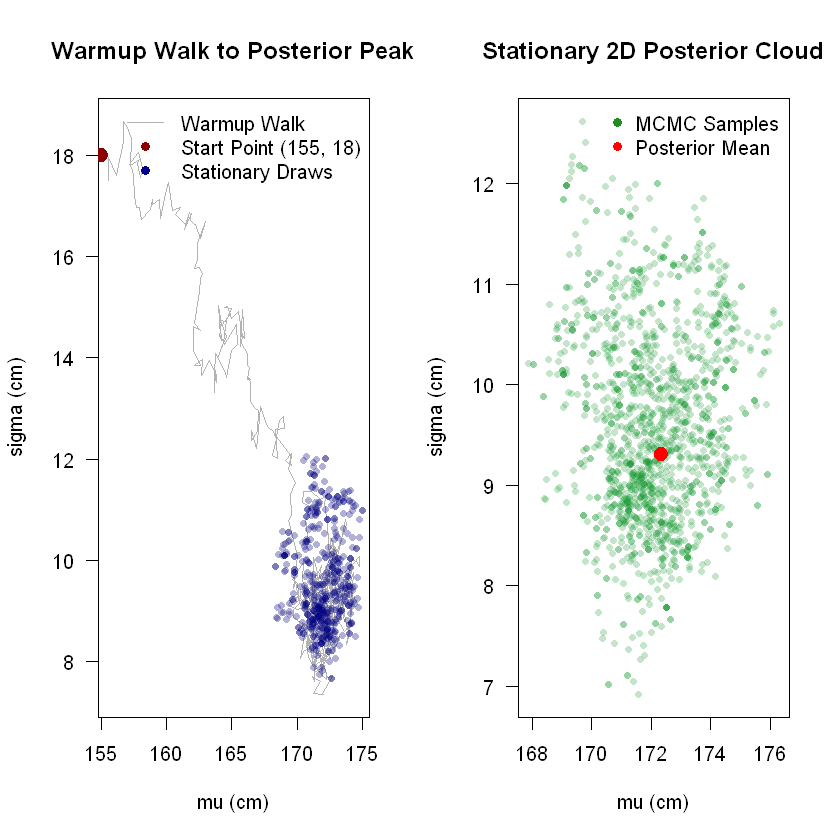

In [12]:
# Visualizing 2D Trajectory and Joint Posterior
par(mfrow = c(1, 2))

plot(chain_2d[1:500, "mu"], chain_2d[1:500, "sigma"], type = "l", col = "gray70", las = 1,
     main = "Warmup Walk to Posterior Peak", xlab = "mu (cm)", ylab = "sigma (cm)")
points(155, 18, col = "darkred", pch = 19, cex = 1.5)
points(post_samples[1:500, "mu"], post_samples[1:500, "sigma"], col = rgb(0, 0, 0.5, 0.3), pch = 16, cex = 0.8)
legend("topright", legend = c("Warmup Walk", "Start Point (155, 18)", "Stationary Draws"),
       col = c("gray70", "darkred", "darkblue"), lty = c(1, NA, NA), pch = c(NA, 19, 16), bty = "n")

plot(post_samples[1:1500, "mu"], post_samples[1:1500, "sigma"], 
     col = rgb(0.1, 0.6, 0.2, 0.25), pch = 16, cex = 0.8, las = 1,
     main = "Stationary 2D Posterior Cloud", xlab = "mu (cm)", ylab = "sigma (cm)")
points(mean(post_samples[, "mu"]), mean(post_samples[, "sigma"]), col = "red", pch = 19, cex = 1.6)
legend("topright", legend = c("MCMC Samples", "Posterior Mean"),
       col = c("forestgreen", "red"), pch = c(16, 19), bty = "n")

par(mfrow = c(1, 1))


## Part 6: Phase VII — The Limits of Random Walks & The Leap to HMC
### *The Curse of Volume & Why High Dimensions Defeat Random Walk Metropolis*

Our from-scratch Random Walk Metropolis worked beautifully for 1 and 2 parameters. But as we scale to modern scientific models (100–10,000 parameters), random walks suffer from a catastrophic geometric bottleneck called **the curse of volume**:

1. **Random Walk Diffusion is Inefficient**: Exploring a $D$-dimensional space with random walk diffusion requires $\mathcal{O}(D^2)$ steps.
2. **The "Thin Crust" Typical Set**: In high dimensions, probability density is highest at the mode, but volume is concentrated in a razor-thin hyper-spherical shell far from the mode. A random proposal chosen uniformly in all directions almost always points *away* from this shell into the vacuum, causing acceptance rates to plummet to zero unless step size is infinitesimally small.

---

### Step 12: The Bridge to Sheet 5 — Hamiltonian Monte Carlo (Stan & PyMC)
In **Sheet 5**, we replace blind random walks with **Hamiltonian Monte Carlo (HMC)**. Instead of staggering around blindly like a drunkard, HMC treats the negative log-posterior like a physical bowl and launches a frictionless particle that glides effortlessly along the contours of the typical set using Newton's laws of motion!


## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): The Acceptance Rate Goldilocks Zone
> **Question**: You implement a Metropolis-Hastings sampler for a multi-parameter posterior:
> - Run A has an acceptance rate of **$94\%$**.
> - Run B has an acceptance rate of **$28\%$**.
> - Run C has an acceptance rate of **$2\%$**.
> 
> Which run is operating in the optimal efficiency zone? Why is an acceptance rate of $94\%$ actually a failure mode rather than a sign of success?


In [13]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
# Compare three MCMC runs:
# Run A: 94% acceptance
# Run B: 28% acceptance
# Run C: 2% acceptance

# 1. Which run is operating in the optimal efficiency zone?
optimal_run <- NA  # "A", "B", or "C"

# 2. What is the danger of Run A (94%)? Explain in comments:


<details>
<summary><b>🔍 Click here to view the solution & Gelman efficiency theorem</b></summary>

**Answer**:
**Run B ($28\%$) is optimal.** (Theoretical optimal for random walk Metropolis is $\sim 23.4\%$ for multidimensional targets, and $\sim 44\%$ for 1D).

**Why 94% is a failure mode**:
An acceptance rate of $94\%$ occurs when the proposal step size $\sigma_{\text{prop}}$ is microscopic. The sampler accepts almost every move because the candidate is virtually identical to the current point. 
However, it takes millions of tiny steps to cross the posterior distribution, resulting in **extreme autocorrelation, glacial exploration speed, and an Effective Sample Size ($ESS$) near zero**. Run C ($2\%$), conversely, proposes massive leaps into the empty tails that are almost always rejected.
</details>


---

### 🟡 Tier 2 (Guided Calculation): Evaluating the Metropolis Acceptance Rule
> **Scenario**: The current state of your Markov chain is $\theta^{(t)} = 175\text{ cm}$, with unnormalized posterior value $p(\theta^{(t)} \mid D) = 0.040$. 
> Your symmetric Gaussian proposal generates candidate $\theta^* = 178\text{ cm}$, with unnormalized posterior value $p(\theta^* \mid D) = 0.010$.
> 1. Calculate the exact acceptance probability $\alpha(\theta^{(t)}, \theta^*)$.
> 2. If a random draw $u \sim \text{Uniform}(0, 1)$ yields $u = 0.42$, is the candidate accepted or rejected?
> 3. What is the value of $\theta^{(t+1)}$ at the next step?


In [14]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
theta_curr <- 175.0
p_curr <- 0.040

theta_cand <- 178.0
p_cand <- 0.010

u_draw <- 0.42

# 1. Compute acceptance probability alpha:
# alpha <- ...

# 2. Decide if accepted:
# is_accepted <- u_draw < alpha

# 3. Next state theta^(t+1):
# theta_next <- if (is_accepted) theta_cand else theta_curr

# cat(sprintf("Alpha: %.2f | Accepted? %s | Next state: %.1f\n", alpha, is_accepted, theta_next))


<details>
<summary><b>🔍 Click here to view the solution & step execution</b></summary>

**Calculation**:
1. Under symmetric proposal $q(\theta^* \mid \theta) = q(\theta \mid \theta^*)$:
   $$\alpha(\theta^{(t)}, \theta^*) = \min\left(1, \frac{p(\theta^* \mid D)}{p(\theta^{(t)} \mid D)}\right) = \min\left(1, \frac{0.010}{0.040}\right) = \min(1, 0.25) = 0.25$$
2. Since $u = 0.42 > \alpha = 0.25$, **the proposed candidate is REJECTED**.
3. **Next State**: The chain does not move. It duplicates the current state:
   $$\theta^{(t+1)} = \theta^{(t)} = 175\text{ cm}$$

```r
p_curr <- 0.040
p_cand <- 0.010
alpha <- min(1.0, p_cand / p_curr)
cat(sprintf('Acceptance Probability alpha: %.2f (25%% chance of accepting)\n', alpha))
```
</details>


---

### 🔴 Tier 3 (Production Challenge): The Hastings Ratio for Asymmetric Proposals
> **Scenario**: Suppose you are estimating a variance parameter $\sigma > 0$ strictly constrained to positive values. Instead of a symmetric normal walk, you propose moves using a Log-Normal distribution centered at the current value:
> $$\theta^* \sim \text{LogNormal}(\log \theta^{(t)}, \tau^2)$$
> 1. Why does the standard Metropolis ratio $\frac{p(\theta^* \mid D)}{p(\theta^{(t)} \mid D)}$ fail to preserve the true target distribution?
> 2. What is the **Hastings correction factor**, and how does it guarantee detailed balance?


In [15]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
theta_curr <- 2.0
theta_cand <- 5.0
tau <- 0.5

# Density of jumping from 2.0 -> 5.0 vs 5.0 -> 2.0 under Log-Normal:
# q_forward <- dlnorm(theta_cand, meanlog = log(theta_curr), sdlog = tau)
# q_reverse <- dlnorm(theta_curr, meanlog = log(theta_cand), sdlog = tau)

# Compute the Hastings correction ratio: q(theta_curr | theta_cand) / q(theta_cand | theta_curr)
# hastings_ratio <- ...
# cat(sprintf("Hastings Ratio: %.4f\n", hastings_ratio))


<details>
<summary><b>🔍 Click here to view the mathematical proof</b></summary>

**Mathematical Proof**:
1. **Asymmetry Violation**: In a Log-Normal distribution, the probability density of jumping from small to large is not equal to jumping from large to small:
   $$q(\theta^* \mid \theta) = \frac{1}{\theta^* \tau \sqrt{2\pi}} \exp\left(-\frac{(\log \theta^* - \log \theta)^2}{2\tau^2}\right)$$
   Notice the denominator has $\theta^*$, whereas $q(\theta \mid \theta^*)$ has $\theta$ in the denominator! Thus $q(\theta^* \mid \theta) \neq q(\theta \mid \theta^*)$. If you use the standard Metropolis rule, the chain will artificially drift toward larger values because jumps upward are inherently favored.
2. **Hastings Correction**: To satisfy detailed balance $\pi(\theta) q(\theta^* \mid \theta) \alpha(\theta, \theta^*) = \pi(\theta^*) q(\theta \mid \theta^*) \alpha(\theta^*, \theta)$, Hastings introduced the transition ratio correction:
   $$\alpha(\theta, \theta^*) = \min\left(1, \frac{p(\theta^* \mid D)}{p(\theta \mid D)} \times \frac{q(\theta \mid \theta^*)}{q(\theta^* \mid \theta)}\right)$$
   For the Log-Normal proposal, the exponential terms cancel, leaving the elegant ratio:
   $$\frac{q(\theta \mid \theta^*)}{q(\theta^* \mid \theta)} = \frac{\theta^*}{\theta}$$
   Multiplying by $\frac{\theta^*}{\theta}$ penalizes upward jumps and encourages downward moves, exactly restoring time-reversibility.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 3b: Discrete Markov Chains & Detailed Balance](03b_markov_chains_and_detailed_balance.ipynb) | ⏭️ Next: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb)**
